<a href="https://colab.research.google.com/github/pablobelmiro/my-AI-mastersdegree-repo/blob/main/Trabalho_reconhecimento_de_padroes_pablo_belmiro_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho de Machine Learning — Pablo Belmiro
**Dataset:** UNSW-NB15 - https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15

## Apresentação

Trabalho desenvolvido por Pablo Belmiro, curso de mestrado em Computação Aplicada (PPCOMP) Instituto Federal do Espírito Santo (Ifes), Campus Serra, como parte da disciplina Reconhecimento de Padrões ministrada por Prof. Francisco de Assis Boldt. O objetivo da atividade é aplicar o ciclo completo de um projeto da matéria de Reconhecimento de Padrões, partindo da contextualização do problema à avaliação do modelo, sobre um conjunto de dados público.

## Problema Escolhido

O problema abordado neste trabalho é a detecção de intrusão em redes de computadores,
utilizando o dataset público UNSW-NB15 disponível no Kaggle.

**Objetivo:** Construir um modelo de classificação capaz de distinguir tráfego de rede
legítimo (normal) de tráfego malicioso (ataques), a partir de características extraídas
dos fluxos de rede.

## Sobre o Dataset UNSW-NB15

O dataset UNSW-NB15 foi criado pelo Australian Centre for Cyber Security (ACCS)
da Universidade de New South Wales, em 2015. Ele foi gerado em um ambiente de
laboratório controlado, combinando tráfego de rede real com ataques sintéticos
produzidos pela ferramenta IXIA PerfectStorm.

### Características principais:
- ~2,5 milhões de registros de fluxos de rede
- 49 features descrevendo características de cada fluxo
- 9 tipos de ataques: Fuzzers, Analysis, Backdoor, DoS, Exploits, Generic,
  Reconnaissance, Shellcode e Worms

### Variável Alvo:
- `Label`: binária, sendo 0 = tráfego normal, 1 = ataque
- `attack_cat`: categórica, possuindo o nome da categoria do ataque (NaN para tráfego normal)

In [2]:
!pip install kaggle -q

import os

os.environ["KAGGLE_USERNAME"] = "pablobelmiro"
os.environ["KAGGLE_KEY"] = "KGAT_24c33da5f755d8ee706aa36ac42a303a"

In [1]:
#download do dataset
import os
os.makedirs("/content/data", exist_ok=True)

arquivos_esperados = ["UNSW-NB15_1.csv", "UNSW_NB15_training-set.csv"]
ja_tem = all(os.path.exists(f"/content/data/{a}") for a in arquivos_esperados)
if ja_tem:
    print("Dados ja presentes em /content/data, pulando download")
else:
    !kaggle datasets download -d mrwellsdavid/unsw-nb15 -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 149M/149M [00:01<00:00, 121MB/s]



In [3]:
print("Arquivos disponíveis em /content/data:\n")
for f in sorted(os.listdir("/content/data")):
    print(f" - {f}")

Arquivos disponíveis em /content/data:

 - NUSW-NB15_features.csv
 - UNSW-NB15_1.csv
 - UNSW-NB15_2.csv
 - UNSW-NB15_3.csv
 - UNSW-NB15_4.csv
 - UNSW-NB15_LIST_EVENTS.csv
 - UNSW_NB15_testing-set.csv
 - UNSW_NB15_training-set.csv


# Carregando os dados

In [4]:
import pandas as pd
from IPython.display import display

features = pd.read_csv("/content/data/NUSW-NB15_features.csv", encoding="latin-1")
features.columns = features.columns.str.strip()
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

print(f"Total de features descritas: {len(features)}")
print()
display(features[["No.", "Name", "Type", "Description"]])

Total de features descritas: 49



,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,"Indicates to the state and its dependent protocol, e.g. ACC, CLO, CON, ECO, ECR, FIN, INT, MAS, PAR, REQ, RST, TST, TXD, URH, URN, and (-) (if not used state)"
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [5]:
import re

# Filtragem apenas dos arquivos de dados -> UNSW-NB15_1.csv até UNSW-NB15_4.csv
partes = sorted([
    f for f in os.listdir("/content/data")
    if re.match(r"UNSW-NB15_\d+\.csv", f)
])

print(f"Arquivos que serão carregados: {partes}\n")

# Extraindo os nomes das colunas do arquivo de features
colunas = features["Name"].tolist()

# Carreganado e concatenando todas as partes em um único DataFrame
df = pd.concat(
    [pd.read_csv(f"/content/data/{p}", header=None, names=colunas, low_memory=False)
     for p in partes],
    ignore_index=True
)

print(f"Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas")

Arquivos que serão carregados: ['UNSW-NB15_1.csv', 'UNSW-NB15_2.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_4.csv']

Dimensões: 2,540,047 linhas x 49 colunas


In [ ]:
print(f"shape do dataset: \n {df.shape}\n\n")
df.head(5)

shape do dataset: 
 (2540047, 49)




,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0


## Análise Exploratória dos dados(EDA)

In [ ]:
from IPython.display import display

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
print()
print("Tipagem dos dados:")
print(df.dtypes.value_counts())
print()

pd.options.display.float_format = "{:,.2f}".format
display(df.describe().T)

Linhas: 2,540,047
Colunas: 49

Tipagem dos dados:
int64      28
float64    12
object      9
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
dur,"2,540,047.00",0.66,13.92,0.00,0.00,0.02,0.21,"8,786.64"
sbytes,"2,540,047.00","4,339.60","56,405.99",0.00,200.00,"1,470.00","3,182.00","14,355,774.00"
dbytes,"2,540,047.00","36,427.59","161,096.04",0.00,178.00,"1,820.00","14,894.00","14,657,531.00"
sttl,"2,540,047.00",62.78,74.62,0.00,31.00,31.00,31.00,255.00
dttl,"2,540,047.00",30.77,42.85,0.00,29.00,29.00,29.00,254.00
sloss,"2,540,047.00",5.16,22.52,0.00,0.00,3.00,7.00,"5,319.00"
dloss,"2,540,047.00",16.33,56.59,0.00,0.00,4.00,14.00,"5,507.00"
Sload,"2,540,047.00","36,956,447.51","118,604,331.28",0.00,"135,396.27","589,303.75","2,039,922.75","5,988,000,256.00"
Dload,"2,540,047.00","2,450,861.22","4,224,862.94",0.00,"11,915.94","589,317.88","2,925,973.50","128,761,904.00"
Spkts,"2,540,047.00",33.29,76.28,0.00,2.00,12.00,44.00,"10,646.00"


## Exploração de dados anômalos

In [ ]:
nulos = df.isnull().sum()
nulos_percentual = (nulos / len(df) * 100)

resumo_nulos = pd.DataFrame({
    "nulos": nulos,
    "percentual": nulos_percentual
}).sort_values("percentual", ascending=False)

apenas_com_nulos = resumo_nulos[resumo_nulos["nulos"] > 0]
print(f"Resumo dos nulos:\n{apenas_com_nulos}")

Resumo dos nulos:
                    nulos  percentual
attack_cat        2218764       87.35
is_ftp_login      1429879       56.29
ct_flw_http_mthd  1348145       53.08


## Visualização dos dados

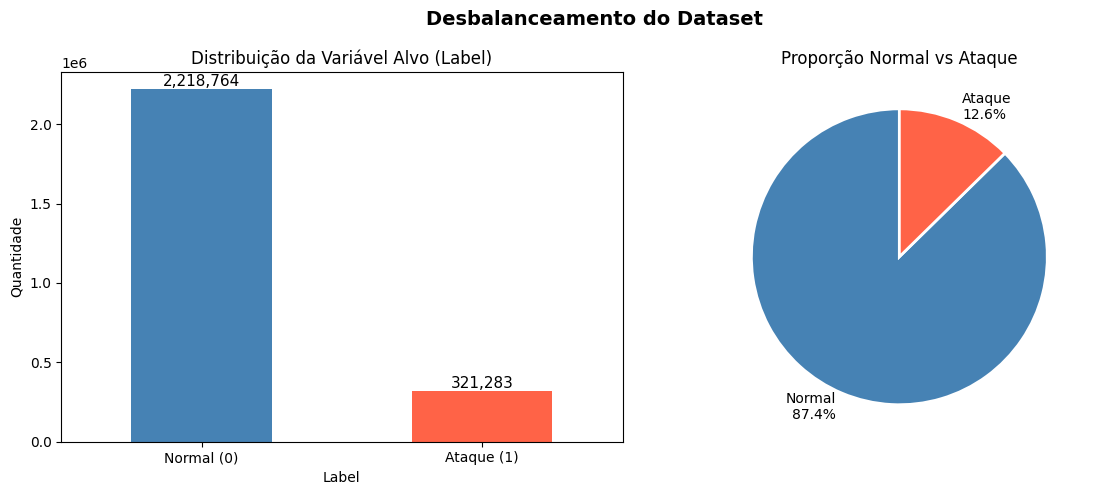


Razão de desbalanceamento: 6.9:1
Isso indica que o dataset é fortemente desbalanceado para a classe Normal.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

contagem_classes = df["Label"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras com anotação dos valores
barras = contagem_classes.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"])
axes[0].set_title("Distribuição da Variável Alvo (Label)")
axes[0].set_xticklabels(["Normal (0)", "Ataque (1)"], rotation=0)
axes[0].set_ylabel("Quantidade")

# Adicionando valor numérico em cima de cada barra
for barra in axes[0].patches:
    axes[0].annotate(
        f'{int(barra.get_height()):,}',
        (barra.get_x() + barra.get_width() / 2., barra.get_height()),
        ha='center', va='bottom', fontsize=11
    )

# Gráfico de pizza
proporcoes = contagem_classes / contagem_classes.sum() * 100
axes[1].pie(
    contagem_classes,
    labels=[f"Normal\n{proporcoes[0]:.1f}%", f"Ataque\n{proporcoes[1]:.1f}%"],
    colors=["steelblue", "tomato"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proporção Normal vs Ataque")

plt.suptitle("Desbalanceamento do Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nRazão de desbalanceamento: {contagem_classes[0]/contagem_classes[1]:.1f}:1")
print(f"Isso indica que o dataset é fortemente desbalanceado para a classe Normal.")

cat_counts: 
 attack_cat
Generic             215481
Exploits             44525
 Fuzzers             19195
DoS                  16353
 Reconnaissance      12228
 Fuzzers              5051
Analysis              2677
Backdoor              1795
Reconnaissance        1759
 Shellcode            1288
Backdoors              534
Shellcode              223
Worms                  174
Name: count, dtype: int64


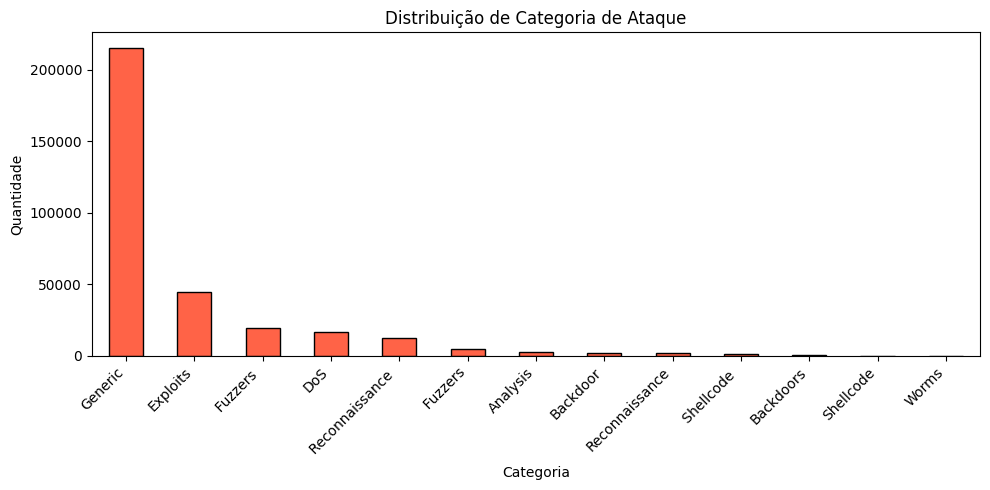

In [ ]:
# Distribuição das categorias de ataque
cat_counts = df["attack_cat"].value_counts()
print(f"cat_counts: \n {cat_counts}")

plt.figure(figsize=(10, 5))
cat_counts.plot(kind="bar", color="tomato", edgecolor="black")
plt.title("Distribuição de Categoria de Ataque")
plt.xlabel("Categoria")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Total de Features numericas: 40


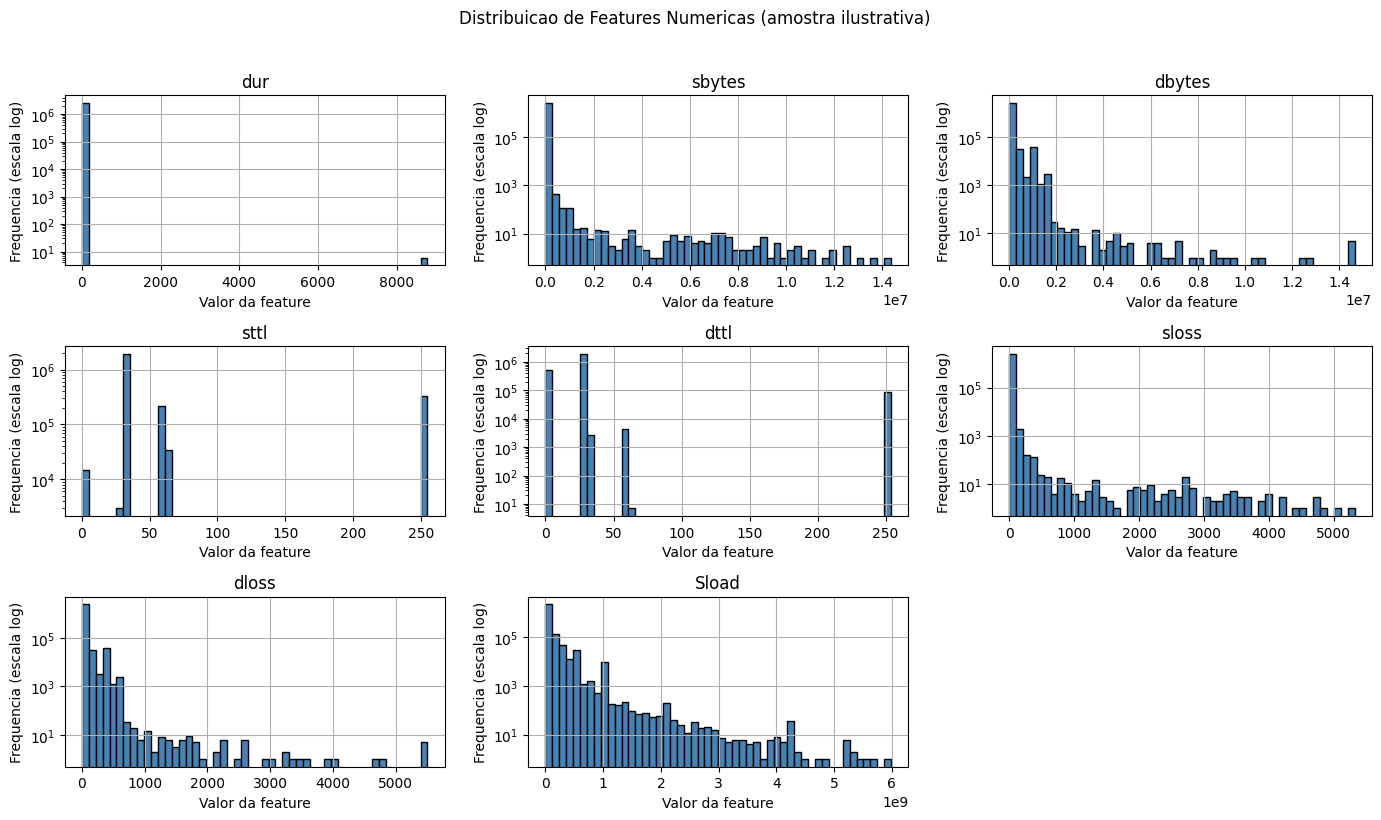

In [ ]:
colunas_numericas = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
print(f"Total de Features numericas: {len(colunas_numericas)}")

# ATENCAO: estas features sao apenas ILUSTRATIVAS (uma amostra para inspecionar a FORMA
# das distribuicoes), e NAO o resultado de uma selecao por importancia. A discussao sobre
# selecao de features esta na celula de texto logo abaixo
# a importancia real e tratada na analise de correlacao (redundancia) e na importancia do Random Forest
features_ilustrativas = ["dur", "sbytes", "dbytes", "sttl", "dttl", "sloss", "dloss", "Sload"]

axes = df[features_ilustrativas].hist(figsize=(14, 8), bins=50, color="steelblue",
                                      edgecolor="black", log=True)
for ax in axes.ravel():
    ax.set_xlabel("Valor da feature")
    ax.set_ylabel("Frequencia (escala log)")

plt.suptitle("Distribuicao de Features Numericas (amostra ilustrativa)", y=1.02)
plt.tight_layout()
plt.show()

### Sobre estas features e a seleção de características

Importante: as oito features acima são ILUSTRATIVAS, uma amostra escolhida apenas para inspecionar a *forma* das distribuições e não o resultado de uma seleção por importância. Em cada subgráfico, o eixo **X** é o valor da feature e o eixo **Y** é a frequência (contagem de fluxos naquele intervalo), em escala logarítmica, porque as distribuições são fortemente assimétricas.

A pergunta "quais features são as mais relevantes?" é central. Há três famílias de seleção de características (tema da aula de seleção de características da disciplina):

- **Filtro (filter):** critérios estatísticos independentes do modelo, por exemplo, a **redundância por correlação** (próxima célula): features quase idênticas carregam a mesma informação, e uma delas pode ser descartada
- **Wrapper:** avaliar subconjuntos de features rodando o próprio modelo, (ex.: RFE) poderoso, porém custoso;
- **Embutida (embedded):** o próprio modelo pontua as features, é o que a **importância do Random Forest** faz mais adiante;

**Decisão deste trabalho:** não podar features no pipeline. A Random Forest é robusta a redundância e à escala, então tratamos a seleção como **análise interpretativa** (entender o que pesa na decisão), e não como uma etapa que altera o modelo, preservando o desempenho já validado. As próximas células dão os dois ângulos: redundância (correlação) e relevância preditiva (importância do modelo).

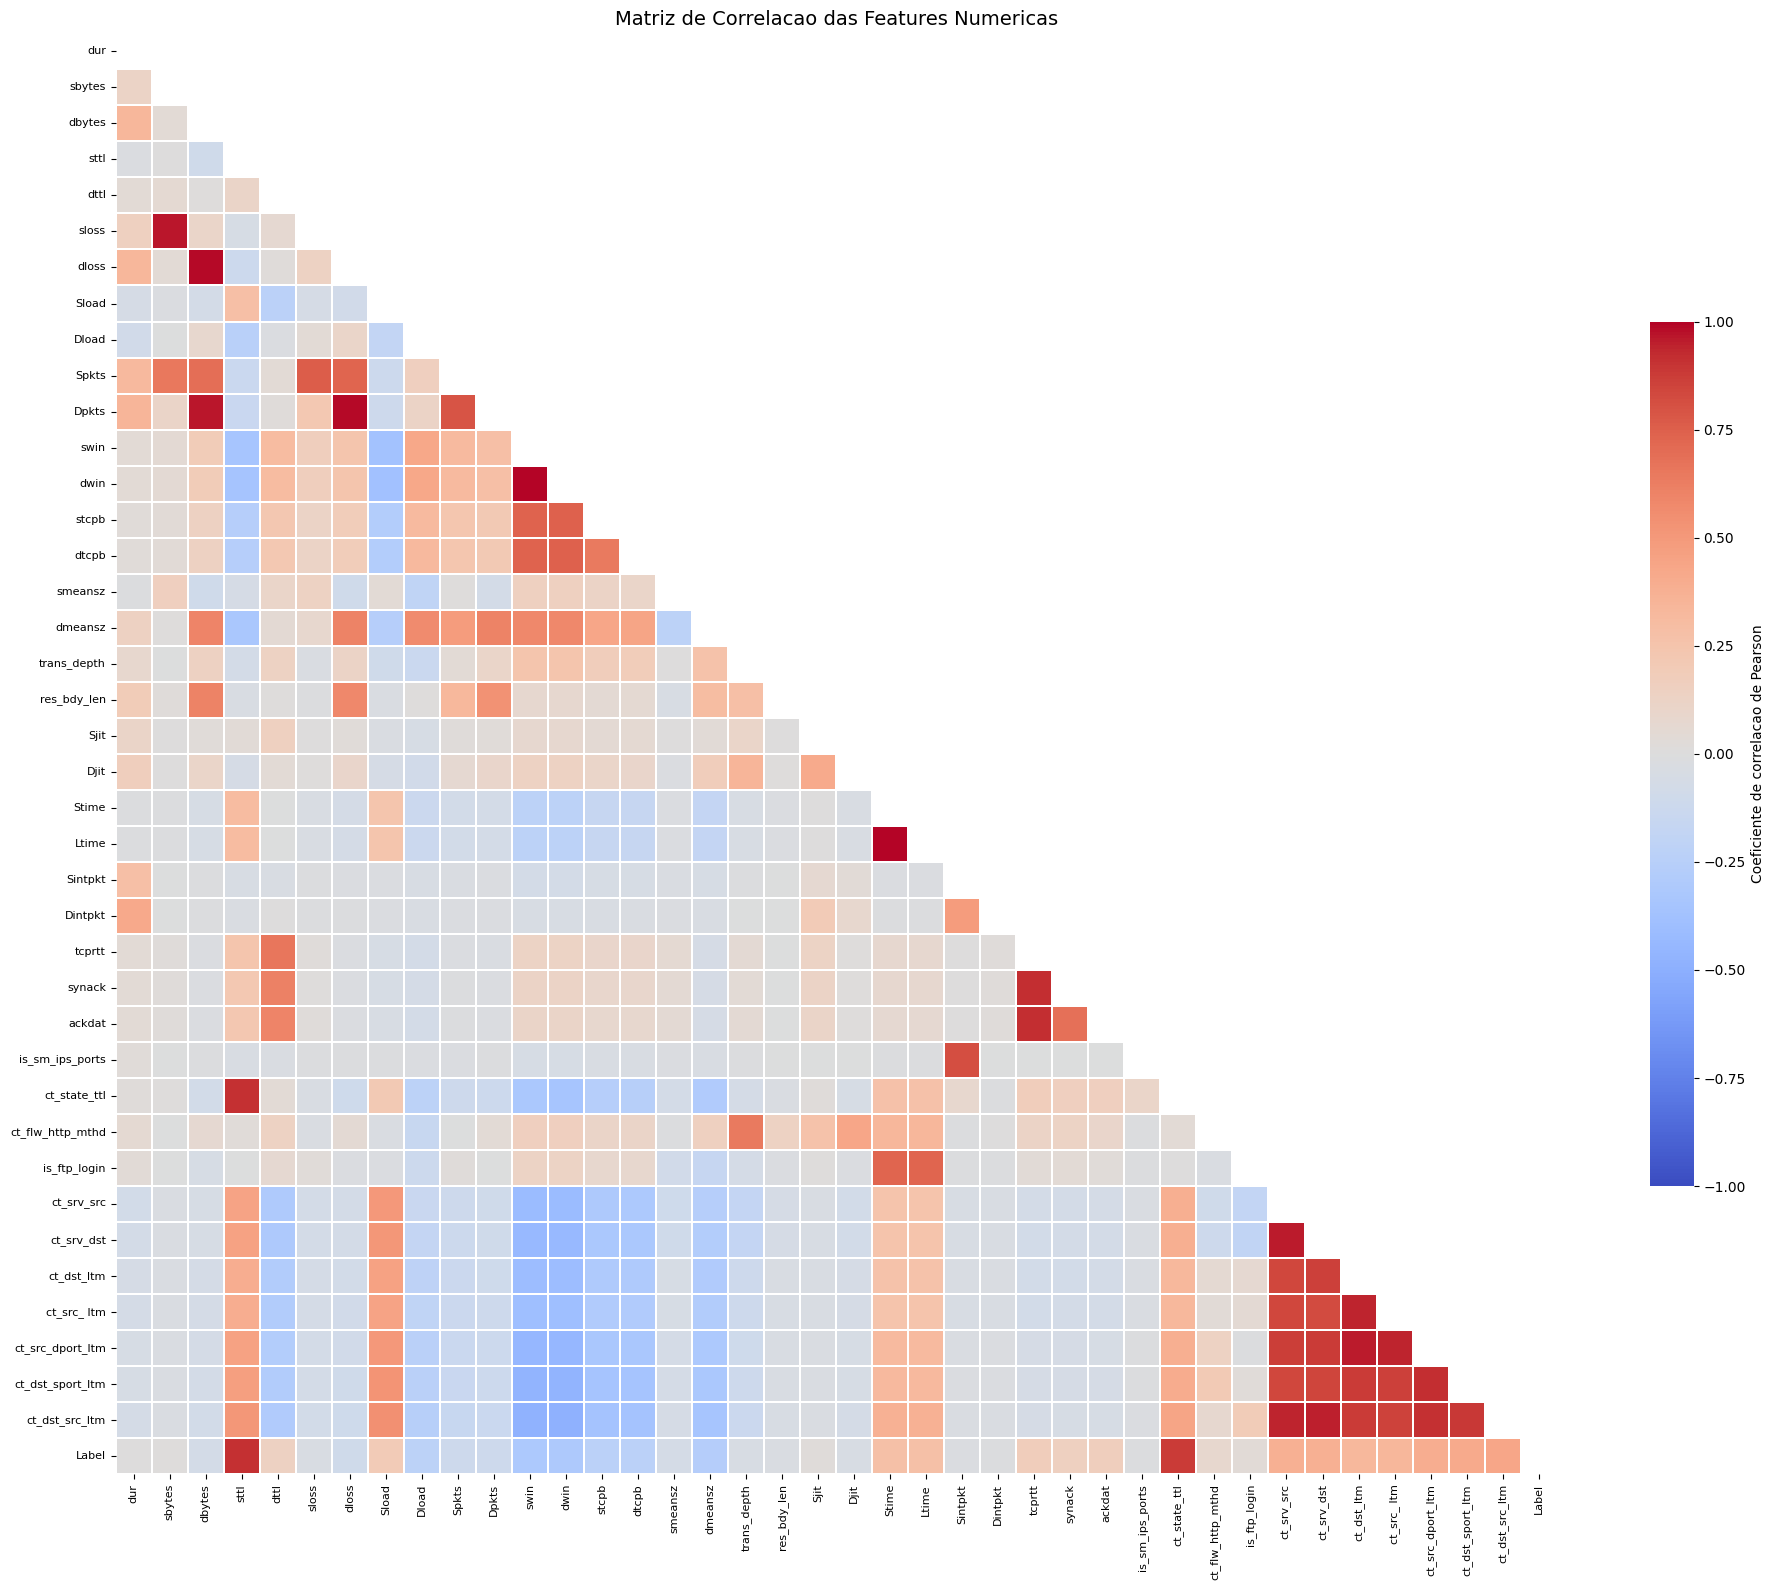

Pares de features altamente correlacionados (|r| >= 0.8):

Stime             Ltime              1.00
swin              dwin               1.00
dloss             Dpkts              0.99
dbytes            dloss              0.99
                  Dpkts              0.97
sbytes            sloss              0.96
ct_dst_ltm        ct_src_dport_ltm   0.96
ct_srv_src        ct_srv_dst         0.96
ct_srv_dst        ct_dst_src_ltm     0.95
ct_src_ ltm       ct_src_dport_ltm   0.95
ct_srv_src        ct_dst_src_ltm     0.94
ct_dst_ltm        ct_src_ ltm        0.94
ct_src_dport_ltm  ct_dst_sport_ltm   0.92
tcprtt            synack             0.92
                  ackdat             0.92
ct_src_dport_ltm  ct_dst_src_ltm     0.91
sttl              ct_state_ttl       0.91
                  Label              0.91
ct_dst_sport_ltm  ct_dst_src_ltm     0.89
ct_dst_ltm        ct_dst_sport_ltm   0.88
                  ct_dst_src_ltm     0.88
ct_state_ttl      Label              0.88
ct_srv_dst       

In [ ]:
import numpy as np

sample = df[colunas_numericas].sample(n=50000, random_state=42)
corr_matrix = sample.corr()

# Mascara o triangulo superior (a matriz e simetrica) para uma leitura mais limpa
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, square=True,
            cbar_kws={"shrink": 0.6, "label": "Coeficiente de correlacao de Pearson"})
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Matriz de Correlacao das Features Numericas", fontsize=14)
plt.tight_layout()
plt.show()

# Pares mais correlacionados (|r| >= 0.8): sinal de REDUNDANCIA (selecao por filtro)
mask_pairs = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_pairs = corr_matrix.where(mask_pairs).stack()
fortes = corr_pairs[corr_pairs.abs() >= 0.8].sort_values(key=abs, ascending=False)
print("Pares de features altamente correlacionados (|r| >= 0.8):")
print()
print(fortes.to_string() if len(fortes) else "Nenhum par com |r| >= 0.8.")

### Como ler a matriz de correlação

Cada quadrícula mede a **correlação de Pearson** entre duas features numéricas. Tons quentes (vermelho) indicam correlação positiva forte, frios (azul), negativa, perto de zero (claro), ausência de relação linear. Mascaramos o triângulo superior porque a matriz é simétrica, assim a leitura fica mais limpa.

Os **blocos quentes** revelam **redundância**, e a tabela impressa abaixo do gráfico lista os pares com |r| ≥ 0,8. Exemplos reais deste dataset: "Stime"/"Ltime" e "swin"/"dwin" (r ≈ 1,00), o trio "dbytes"/"dloss"/"Dpkts" (r ≈ 0,99) e diversos contadores de conexão "ct_*" entre si (r ≈ 0,94–0,96). Esses pares carregam quase a mesma informação.

Na prática, redundância alta é candidata natural a **redução por filtro** (manter uma feature de cada grupo) ou a **PCA**. Mantemos todas porque a Random Forest lida bem com features correlacionadas, mas registrar a redundância é parte da análise de seleção discutida acima.

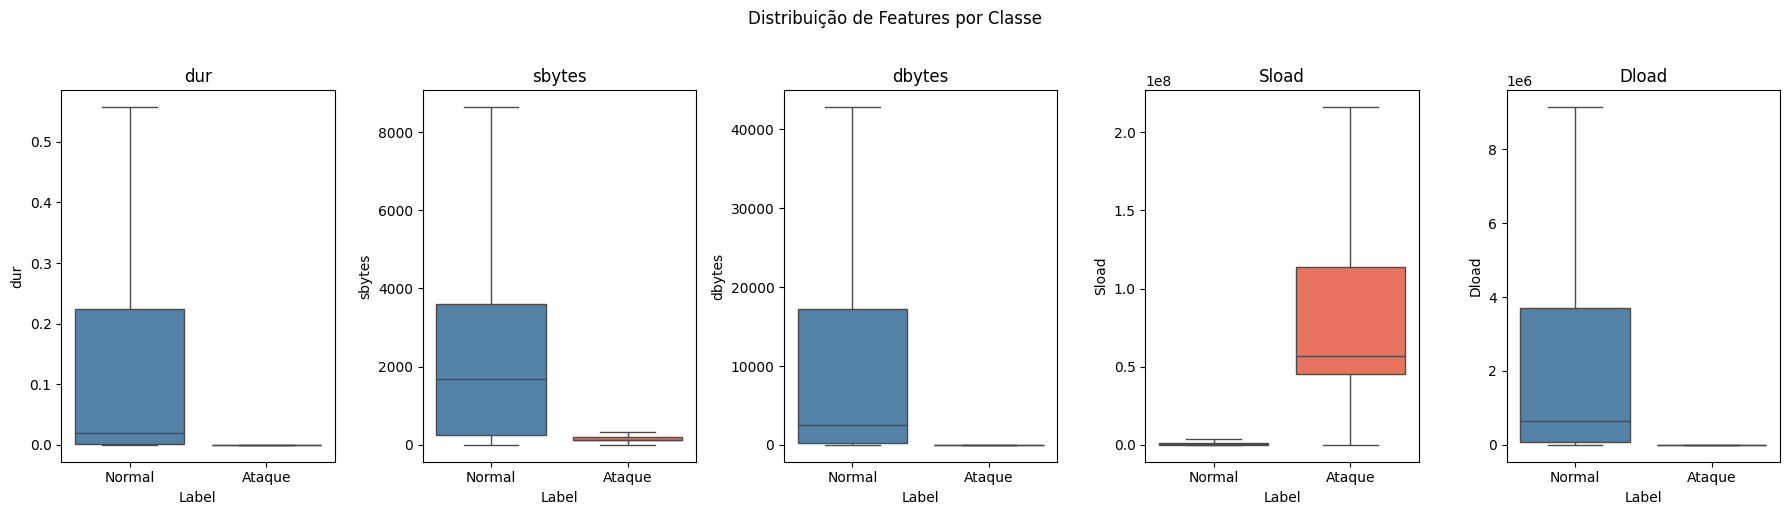

In [ ]:
features_box = ["dur", "sbytes", "dbytes", "Sload", "Dload"]

fig, axes = plt.subplots(1, len(features_box), figsize=(18, 5))

for i, feat in enumerate(features_box):
    sns.boxplot(
        data=df,
        x="Label",
        y=feat,
        ax=axes[i],
        palette=["steelblue", "tomato"],
        showfliers=False,   # tirando outliers extremos para melhor visualização
        hue="Label",
        legend=False
    )
    axes[i].set_title(feat)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Normal", "Ataque"])

plt.suptitle("Distribuição de Features por Classe", y=1.02)
plt.tight_layout()
plt.show()

### Como ler os boxplots por classe

Cada boxplot compara a distribuição de uma feature entre **tráfego Normal e Ataque**. A linha central é a **mediana**. a caixa vai do 1º ao 3º quartil (os 50% centrais dos dados). Os "bigodes" cobrem a dispersão típica. Omitimos os *outliers* extremos (showfliers=False) apenas para a visualização não ficar achatada. Eles existem e são relevantes.

A leitura-chave é o poder discriminativo**: quando as caixas de Normal e Ataque ficam em faixas de valores claramente diferentes (pouca sobreposição), aquela feature ajuda a separar as classes
 quando se sobrepõem quase por completo, a feature sozinha discrimina pouco. É uma inspeção visual que antecipa o que a importância do modelo confirma de forma quantitativa mais adiante.

In [ ]:
# identificar colunas categóricas (object)
categoricas = df.select_dtypes(include=["object"]).columns.tolist()
print("Colunas categóricas:", categoricas)

# Distribuição de cada uma
for col in categoricas:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))

Colunas categóricas: ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'service', 'ct_ftp_cmd', 'attack_cat']

srcip:
srcip
59.166.0.4    197959
59.166.0.1    197680
59.166.0.5    197626
59.166.0.2    197550
59.166.0.0    197528
59.166.0.3    195953
59.166.0.9    190187
59.166.0.6    189419
59.166.0.8    189341
59.166.0.7    189059
Name: count, dtype: int64

sport:
sport
1043     214363
47439    196337
0         44376
0          9668
47439      6932
1043       5959
138        3480
5060        448
137         362
2048        357
Name: count, dtype: int64

dstip:
dstip
149.171.126.3    197771
149.171.126.2    197648
149.171.126.4    197639
149.171.126.1    197535
149.171.126.5    197000
149.171.126.0    196770
149.171.126.9    190483
149.171.126.7    190268
149.171.126.6    189709
149.171.126.8    187479
Name: count, dtype: int64

dsport:
dsport
53      798968
80      226698
6881    125156
5190    120599
111      93296
25       88748
0        54091
143      51065
22       50827
21 

### O que as distribuições categóricas mostram

Aqui contamos os valores mais frequentes de cada coluna categórica. Destaques: "proto" é dominado por **tcp** e **udp**, "state" por **FIN/CON/INT**, e"service" tem um grande "-" (serviço não identificado), além de **dns** e **http**. Também aparecem identificadores de altíssima cardinalidade ("srcip", "dstip", "sport", "dsport"), com milhares de valores distintos.

Isso tem duas consequências para a modelagem: (1) features de **baixa cardinalidade e sem ordem** (proto, service, state) são boas candidatas a **One-Hot Encoding**. (2) os **identificadores de rede** de altíssima cardinalidade são descartados, tanto por inflarem a dimensionalidade quanto, principalmente, pelo risco de *data leakage* discutido na metodologia.

## Análise de Valores Ausentes

Identificar colunas com valores nulos é essencial antes de qualquer modelagem.
Nulos podem indicar falhas de coleta, features irrelevantes para certos protocolos,
ou exigir estratégias específicas de tratamento (imputação ou remoção).

**Observação importante:** `attack_cat` tem 87% de nulos porque essa coluna só
é preenchida quando o tráfego é um ataque (Label=1). Registros normais (Label=0)
naturalmente ficam vazios, isso **não é um problema de qualidade**, é um comportamento
esperado da estrutura do dataset.

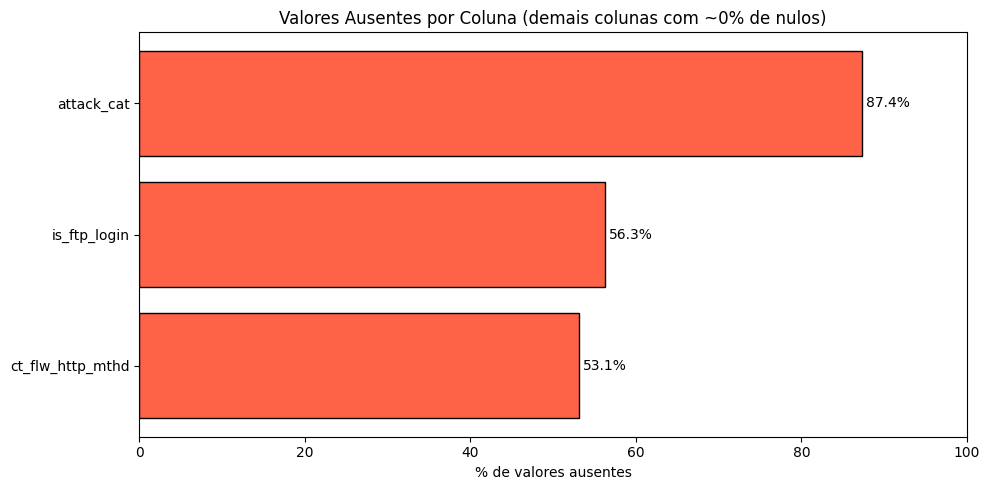

In [ ]:
import matplotlib.pyplot as plt

# Percentual de valores ausentes por coluna (apenas as que possuem nulos)
nulos_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
nulos_pct = nulos_pct[nulos_pct > 0]

plt.figure(figsize=(10, 5))
barras = plt.barh(nulos_pct.index[::-1], nulos_pct.values[::-1], color="tomato", edgecolor="black")
for b, v in zip(barras, nulos_pct.values[::-1]):
    plt.text(v + 0.5, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", fontsize=10)
plt.xlabel("% de valores ausentes")
plt.title("Valores Ausentes por Coluna (demais colunas com ~0% de nulos)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Por que trocamos o gráfico de valores ausentes

O mapa anterior (heatmap de 5.000 amostras) era difícil de ler: com poucas colunas e milhares de linhas, virava uma tira estreita sem informação clara. Substituímos por um **gráfico de barras do percentual de ausentes por coluna**, que responde diretamente à pergunta "quanto falta em cada coluna?".

A leitura confirma a natureza **estrutural** das ausências: "attack_cat" (~87%) só é preenchida quando há ataque, "is_ftp_login" (~56%) e "ct_flw_http_mthd" (~53%) só fazem sentido para sessões FTP e HTTP. **As demais colunas têm ~0% de nulos.** Ou seja, não há um problema de coleta para imputar às cegas a ausência tem significado, e a partição oficial usada na modelagem já vem sem esses buracos.

## Principais Insights da EDA

A análise exploratória revelou os seguintes pontos críticos para a fase de modelagem:

### 1. Desbalanceamento Severo
- ~87,4% dos registros são tráfego normal e ~12,6% são ataques
- Impacto na modelagem: será necessário usar técnicas como class_weight='balanced',
  SMOTE, ou métricas que não sejam enganadas pelo desbalanceamento (F1-score, AUC-ROC)

### 2. Valores Ausentes Estruturais
- `attack_cat` (87% nulos): nulos esperados, registros normais não têm categoria de ataque
- `is_ftp_login` (56% nulos) e `ct_flw_http_mthd` (53% nulos): features protocolares
  que só fazem sentido para conexões FTP e HTTP respectivamente
- Demais colunas (0,008% nulos): 209 linhas com problemas candidatas à remoção simples

### 3. Problemas de Qualidade Encontrados e Corrigidos
- `attack_cat`: espaços à esquerda criavam categorias duplicadas (" Fuzzers" ≠ "Fuzzers")
- `ct_ftp_cmd`: strings vazias sendo tratadas como categoria ao invés de nulo

### 4. Distribuição Assimétrica das Features
- Praticamente todas as features numéricas têm distribuição altamente assimétrica
- Impacto na modelagem: algoritmos baseados em distância (KNN) e lineares (Regressão Logística)
  serão muito sensíveis a isso, normalização/padronização será necessária

### 5. Alta Correlação entre Algumas Features
- Features como `sbytes`/`dbytes` e `Sload`/`Dload` tendem a ser correlacionadas
- Pode indicar oportunidade de redução de dimensionalidade (PCA) ou seleção de features

### 6. Ataques Predominantes
- `Generic` é o tipo mais frequente, seguido de `Exploits` e `Fuzzers`
- A distribuição é desigual entre categorias relevante para classificação multiclasse

## Metodologia: Escolha da Partição de Dados

Antes de modelar, é preciso decidir **quais dados** usar. O dataset oferece duas opções:

1. **Arquivos brutos** (`UNSW-NB15_1.csv` a `_4.csv`): ~2,5 milhões de fluxos, com identificadores de rede (`srcip`, `dstip`, `sport`, `dsport`) e timestamps (`Stime`, `Ltime`).
2. **Partição oficial** (`UNSW_NB15_training-set.csv` e `UNSW_NB15_testing-set.csv`): subconjunto curado pelos autores (Moustafa & Slay, 2015), já sem identificadores nem timestamps.

**Decisão: usaremos a partição oficial.** Justificativa metodológica:

- **Prevenção de *data leakage***: IPs e portas identificam máquinas específicas do laboratório. Um modelo treinado com eles "decoraria" endereços em vez de aprender o comportamento do ataque, inflando artificialmente o desempenho e sem generalizar para outras redes. Timestamps (`Stime`/`Ltime`) têm o mesmo risco.
- **Comparabilidade (benchmark)**: a partição oficial é o padrão da literatura, permitindo comparar nossos resultados com outros trabalhos de forma justa.
- **Split confiável**: usar a separação treino/teste já definida pelos autores evita o vazamento que um split aleatório sobre fluxos correlacionados (mesma sessão/host) poderia causar.

Em resumo, abrir mão de ~2,5M de registros é uma troca consciente: priorizamos **validade metodológica e generalização** em vez de volume bruto de dados.

In [ ]:
import pandas as pd

# Carregar a partição oficial (curada pelos autores do dataset)
df_train = pd.read_csv("/content/data/UNSW_NB15_training-set.csv")
df_test  = pd.read_csv("/content/data/UNSW_NB15_testing-set.csv")

print("Treino:", df_train.shape)
print("Teste :", df_test.shape)
print("\nColunas:", list(df_train.columns))
df_train.head()

Treino: (82332, 45)
Teste : (175341, 45)

Colunas: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.00,udp,-,INT,2,0,496,0,"90,909.09",...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.00,udp,-,INT,2,0,1762,0,"125,000.00",...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.00,udp,-,INT,2,0,1068,0,"200,000.01",...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.00,udp,-,INT,2,0,900,0,"166,666.66",...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.00,udp,-,INT,2,0,2126,0,"100,000.00",...,1,3,0,0,0,2,3,0,Normal,0


### As colunas da partição oficial

Diferença importante: a partição oficial (training-set / testing-set) não tem as mesmas colunas dos arquivos brutos. Os autores removeram os identificadores (srcip, dstip, sport, dsport) e os timestamps, e mantiveram um conjunto de features já **prontas**, que podem ser agrupadas em:

- **Básicas do fluxo:** dur (duração), proto, service, state.
- **Volume e taxa:** spkts/dpkts (pacotes), sbytes/dbytes (bytes), rate, sload/dload (carga)
- **TCP e tempo:** sttl/dttl (time-to-live), swin/dwin (janela TCP), tcprtt, synack, ackdat;
- **Contadores de conexão (ct_...):** quantas conexões recentes compartilham serviço, host ou porta — capturam padrões de varredura e repetição típicos de ataques
- **Alvos:** label (binário 0/1) e attack_cat (categoria do ataque)

Por isso a EDA (feita nos arquivos brutos) e a modelagem (feita na partição) não mapeiam 1:1, uma diferença que assumimos conscientemente em troca de comparabilidade com a literatura e ausência de vazamento.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 'id' identifica a linha, 'attack_cat' e 'label' sao alvos -> nao entram em X
DESCARTAR = ["id", "attack_cat", "label"]
X_train = df_train.drop(columns=[c for c in DESCARTAR if c in df_train.columns])
y_train = df_train["label"]
X_test = df_test.drop(columns=[c for c in DESCARTAR if c in df_test.columns])
y_test = df_test["label"]

# Identifica tipos de coluna automaticamente
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
print("Categoricas:", cat_cols)
print("No de numericas:", len(num_cols))

# Padroniza numericas e aplica One-Hot nas categoricas
transformadores = [("num", StandardScaler(), num_cols), ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)]
preprocessador = ColumnTransformer(transformers=transformadores)
print("Pre-processador configurado.")

Categoricas: ['proto', 'service', 'state']
No de numericas: 39
Pre-processador configurado.


### O que o pré-processador faz (e por que não há saída visível)

Esta célula não gera gráfico nem número: ela apenas **monta** o transformador que será aplicado depois, dentro do pipeline. O ColumnTransformer aplica, em paralelo:
- **StandardScaler** nas colunas numéricas (centra em média 0 e desvio 1). essencial para a regressão logística e inócuo para as árvores;
- **OneHotEncoder** nas categóricas (proto, service, state), com handle_unknown ignorando categorias novas no teste, para não quebrar a execução.

O ponto crucial é que isso fica dentro do pipeline: assim, na validação cruzada, o scaler aprende a média e o desvio apenas com o fold de treino, evitando *data leakage* do fold de validação. A saída esperada é apenas a confirmação de que o pré-processador foi configurado.

## Seleção do Modelo: Comparação Justa entre Candidatos

Em vez de escolher um modelo arbitrariamente, comparamos quatro famílias com configurações padrão (sem ajuste de hiperparâmetros), avaliadas **na mesma validação cruzada estratificada**. Cada modelo carrega uma hipótese diferente sobre os dados:

- **Regressão Logística**: assume fronteira de decisão linear, serve como referência simples e interpretável.
- **Árvore de Decisão**: captura relações não lineares, mas tende a *overfitting*
- **Random Forest**: agrega muitas árvores (reduz variância via *bagging*)
- **Naive Bayes Gaussiano**: assume independência entre features, é rápido, bom como linha de base.

**Critério de seleção (definido antes de ver os números):** priorizamos o **F1-score** (equilíbrio entre não deixar ataques passarem e não gerar alarmes falsos), usando **ROC-AUC** como desempate. Como as classes são desbalanceadas, usamos `class_weight="balanced"` onde aplicável e validação **estratificada** (mantém a proporção de classes em cada *fold*).

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

# Para a SELECAO de modelo usamos uma amostra estratificada (mais rapido)
#O modelo escolhido sera depois treinado em TODO o conjunto de treino na avaliacao final
Xs = X_train.sample(n=20000, random_state=42)
ys = y_train.loc[Xs.index]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
modelos = {"Regressao Logistica": LogisticRegression(max_iter=1000, class_weight="balanced"), "Arvore de Decisao": DecisionTreeClassifier(random_state=42, class_weight="balanced"), "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1), "Naive Bayes": GaussianNB()}
score = lambda clf, m: cross_val_score(Pipeline([("prep", preprocessador), ("clf", clf)]), Xs, ys, cv=cv, scoring=m, n_jobs=-1).mean()
linhas = [{"Modelo": n, "F1": score(c, "f1"), "AUC": score(c, "roc_auc")} for n, c in modelos.items()]
tabela = pd.DataFrame(linhas).sort_values("F1", ascending=False).reset_index(drop=True)
print(tabela.round(4))
tabela.round(4)

                Modelo   F1  AUC
0        Random Forest 0.97 1.00
1    Arvore de Decisao 0.95 0.95
2  Regressao Logistica 0.92 0.98
3          Naive Bayes 0.54 0.72


,Modelo,F1,AUC
0,Random Forest,0.97,1.00
1,Arvore de Decisao,0.95,0.95
2,Regressao Logistica,0.92,0.98
3,Naive Bayes,0.54,0.72


### Comparação de modelos

Esta tabela é o coração da **seleção de modelo**. Cada linha é uma família de algoritmos, avaliada na **mesma validação cruzada estratificada** (folds que preservam a proporção das classes), sobre uma amostra de 20.000 fluxos para agilizar. As colunas são as métricas escolhidas **antes** de ver os resultados: **F1** (equilíbrio entre capturar ataques e evitar alarmes falsos) e **AUC** (poder de separação independente do limiar).

A expectativa teórica é que a **Random Forest** lidere: ela combina o baixo viés das árvores com a baixa variância do *bagging*. Por isso é ela a escolhida para o treino final em todo o conjunto, na próxima etapa.

## Avaliação Final no Conjunto de Teste Oficial

A comparação apontou a **Random Forest** como melhor modelo (maior F1 e AUC), confirmando a expectativa teórica de que o *ensemble* controla a variância e captura as relações não lineares do tráfego de rede.

Agora treinamos o modelo escolhido em todo o conjunto de treino e o avaliamos no **testing-set oficial**, dados nunca vistos no treino. Essa é a estimativa honesta de desempenho em produção. Reportamos *precision*, *recall* e *F1* (e não apenas acurácia, por causa do desbalanceamento), a **matriz de confusão** (com foco nos falsos negativos ataques que escapam) e a **importância das features**.

              precision    recall  f1-score   support

           0     0.7798    0.9759    0.8669     56000
           1     0.9872    0.8707    0.9253    119341

    accuracy                         0.9043    175341
   macro avg     0.8835    0.9233    0.8961    175341
weighted avg     0.9210    0.9043    0.9067    175341



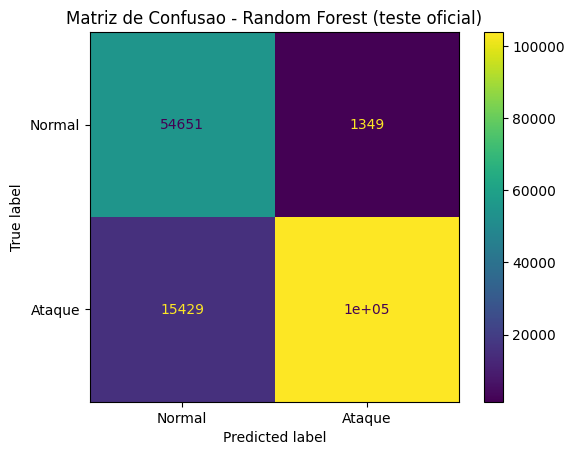

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Modelo final: Random Forest treinado em TODO o conjunto de treino
modelo_final = Pipeline([("prep", preprocessador), ("clf", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1))])
modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Normal", "Ataque"])
plt.title("Matriz de Confusao - Random Forest (teste oficial)")
plt.show()

### Lendo a avaliação no teste oficial

Estes são os resultados do modelo final (Random Forest treinada em todo o conjunto de treino) sobre o **testing-set oficial**, nunca visto. Em números reais: **acurácia ≈ 0,904**, **F1 da classe Ataque ≈ 0,925** (precisão 0,987, recall **0,871**), F1 da classe Normal ≈ 0,867.

A matriz de confusão deve ser lida com foco nos **falsos negativos**, ataques classificados como normais. O recall de ataque de **0,871** significa que cerca de **13% dos ataques escapam**: é o erro mais caro em segurança e o que mais nos interessa reduzir (por exemplo, baixando o limiar de decisão, o que a curva ROC a seguir permite analisar). Observação: na partição oficial, a classe Ataque é a **majoritária** no teste (119.341 contra 56.000 Normal), o oposto dos arquivos brutos.

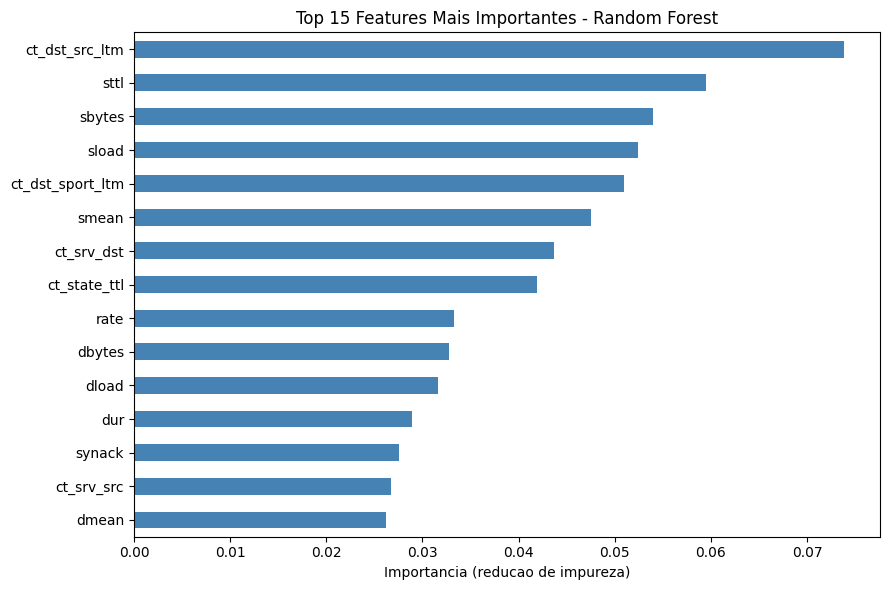

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Recupera os nomes das features apos o One-Hot Encoding
ohe = modelo_final.named_steps["prep"].named_transformers_["cat"]
nomes_cat = ohe.get_feature_names_out(cat_cols)
nomes_features = np.concatenate([num_cols, nomes_cat])

importancias = modelo_final.named_steps["clf"].feature_importances_
imp = pd.Series(importancias, index=nomes_features).sort_values(ascending=False)

imp.head(15).iloc[::-1].plot(kind="barh", figsize=(9, 6), color="steelblue")
plt.title("Top 15 Features Mais Importantes - Random Forest")
plt.xlabel("Importancia (reducao de impureza)")
plt.tight_layout()
plt.show()

### O que dizem as features mais importantes

Este gráfico mostra as features que mais reduziram a impureza nas árvores, a visão **embutida (embedded)** de seleção. No topo aparecem, de forma coerente com a literatura do UNSW-NB15 e com a EDA, três grupos:
- **TTL (time-to-live):** sttl, dttl e ct_state_ttl o "tempo de vida" dos pacotes e o estado da conexão são fortíssimos discriminadores, pois os ataques sintéticos tendem a ter assinaturas de TTL distintas.
- **Contadores de conexão (ct_...):** capturam varredura e repetição (muitas conexões recentes ao mesmo host, serviço ou porta).
- **Volume e carga:** bytes e taxa de transferência (sbytes, sload, etc.).

Duas ressalvas de rigor: (1) a importância por impureza é **enviesada** para features de alta cardinalidade, a *permutation importance* seria mais robusta. (2) importância **não é causalidade**: indica utilidade preditiva, não o mecanismo do ataque.

## Avaliação Complementar: Curva ROC e AUC

A matriz de confusão acima avalia o modelo em **um único limiar de decisão** (o padrão, 0,5). Mas a Random Forest não devolve apenas um rótulo: para cada fluxo ela estima uma probabilidade P(ataque | x). A escolha do limiar é, na prática, uma decisão operacional de segurança, baixá-lo aumenta o *recall* (capturamos mais ataques) ao custo de mais falsos positivos.

A **curva ROC** (*Receiver Operating Characteristic*) torna esse compromisso explícito: varrendo todos os limiares possíveis, ela traça a Taxa de Verdadeiros Positivos (recall) contra a Taxa de Falsos Positivos (1 especificidade). O **AUC** (*Area Under the Curve*) condensa a curva em um único número com interpretação probabilística elegante: é a probabilidade de o modelo atribuir um escore maior a um ataque sorteado ao acaso do que a um tráfego normal sorteado ao acaso. AUC = 1,0 é o classificador perfeito, AUC = 0,5 equivale ao palpite aleatório (a diagonal pontilhada).

Reportamos o AUC porque ele é **independente do limiar** e **menos sensível ao desbalanceamento** do que a acurácia, complementando o F1 já apresentado e atendendo à recomendação do enunciado de incluir curvas ROC na avaliação.

AUC-ROC no conjunto de teste oficial: 0.9830


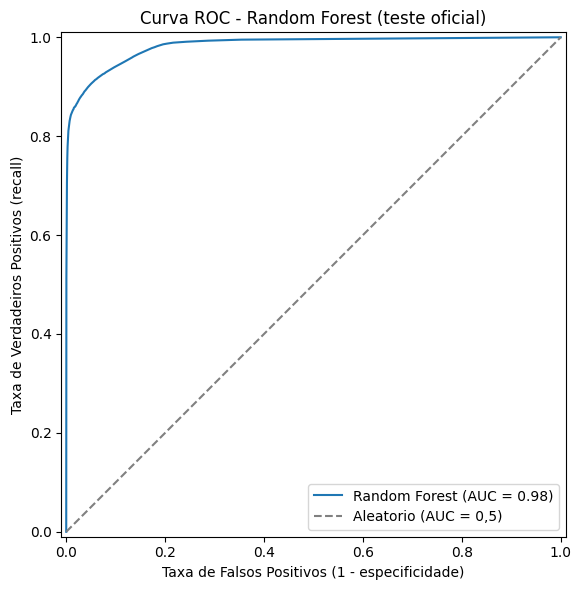

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Random Forest final estima P(ataque | x), probabilidade da classe 1 (ataque)
y_score = modelo_final.predict_proba(X_test)[:, 1]

# AUC no conjunto de teste oficial: metrica independente do limiar de decisao
auc = roc_auc_score(y_test, y_score)
print(f"AUC-ROC no conjunto de teste oficial: {auc:.4f}")

# Curva ROC: trade-off entre capturar ataques (recall) e gerar alarmes falsos
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_score, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio (AUC = 0,5)")
ax.set_title("Curva ROC - Random Forest (teste oficial)")
ax.set_xlabel("Taxa de Falsos Positivos (1 - especificidade)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (recall)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Lendo a curva ROC

A explicação conceitual da ROC e do AUC está na célula de texto acima, o resultado: o modelo alcançou **AUC = 0,983** no teste oficial. A curva colada ao canto superior esquerdo (bem acima da diagonal pontilhada do acaso) indica **excelente poder de separação** entre normal e ataque, de forma **independente do limiar**. É essa folga que permitiria, se quiséssemos mais recall de ataque, baixar o limiar de 0,5 com um custo controlado de falsos positivos.

## Otimização de Hiperparâmetros (GridSearchCV)

Até aqui a Random Forest usou os hiperparâmetros padrão. Esta etapa fecha o **ciclo de otimização** (tema da aula de GridSearch da disciplina): em vez de aceitar os valores default, buscamos sistematicamente a melhor combinação.

O **GridSearchCV** testa todas as combinações de uma grade de hiperparâmetros, avaliando cada uma por **validação cruzada estratificada** (a mesma lógica da seleção de modelo) e escolhendo a de melhor **F1**. Para manter o custo tratável, fazemos a busca sobre uma **amostra estratificada** de 30.000 fluxos, em seguida, **re-treinamos a melhor configuração em todo o conjunto de treino** e a avaliamos no teste oficial, comparando com a RF padrão (F1 ataque = 0,925, AUC = 0,983, acurácia = 0,904).

A grade explora três alavancas clássicas da Random Forest:
- **n_estimators**: número de árvores (mais árvores reduzem variância, ao custo de tempo);
- **max_depth**: profundidade máxima (controla o overfitting);
- **min_samples_leaf**: mínimo de amostras por folha (suaviza a fronteira de decisão).

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from IPython.display import display
import pandas as pd

# Busca em uma amostra estratificada para manter o custo tratavel (mesma logica da selecao de modelo)
Xg = X_train.sample(n=30000, random_state=42)
yg = y_train.loc[Xg.index]

pipe_rf = Pipeline([("prep", preprocessador),
                    ("clf", RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1))])

param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 30],
    "clf__min_samples_leaf": [1, 2],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(pipe_rf, param_grid, scoring="f1", cv=cv, n_jobs=-1, verbose=1)
grid.fit(Xg, yg)

print("Melhores hiperparametros:", grid.best_params_)
print(f"Melhor F1 (CV na amostra): {grid.best_score_:.4f}")
print()

resultados = pd.DataFrame(grid.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
display(resultados.sort_values("rank_test_score").reset_index(drop=True))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores hiperparametros: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Melhor F1 (CV na amostra): 0.9716



,params,mean_test_score,std_test_score,rank_test_score
0,"{'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}",0.97,0.00,1
1,"{'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}",0.97,0.00,2
2,"{'clf__max_depth': 30, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}",0.97,0.00,3
3,"{'clf__max_depth': 30, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}",0.97,0.00,4
4,"{'clf__max_depth': 30, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 400}",0.97,0.00,5
5,"{'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 400}",0.97,0.00,6
6,"{'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}",0.97,0.00,7
7,"{'clf__max_depth': 30, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}",0.97,0.00,8


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Re-treina a melhor configuracao em TODO o conjunto de treino e avalia no teste oficia
melhores = {k.replace("clf__", ""): v for k, v in grid.best_params_.items()}
modelo_tunado = Pipeline([("prep", preprocessador),
                          ("clf", RandomForestClassifier(random_state=42, class_weight="balanced",
                                                         n_jobs=-1, **melhores))])
modelo_tunado.fit(X_train, y_train)
y_pred_t = modelo_tunado.predict(X_test)
y_score_t = modelo_tunado.predict_proba(X_test)[:, 1]

print("=== Random Forest AJUSTADA (teste oficial) ===")
print(classification_report(y_test, y_pred_t, digits=4))
print(f"AUC-ROC (ajustada): {roc_auc_score(y_test, y_score_t):.4f}")
print()
print("Baseline RF padrao  ->  F1 ataque: 0.9253 | AUC: 0.9830 | acuracia: 0.9043")

=== Random Forest AJUSTADA (teste oficial) ===
              precision    recall  f1-score   support

           0     0.7798    0.9759    0.8669     56000
           1     0.9872    0.8707    0.9253    119341

    accuracy                         0.9043    175341
   macro avg     0.8835    0.9233    0.8961    175341
weighted avg     0.9210    0.9043    0.9067    175341

AUC-ROC (ajustada): 0.9830

Baseline RF padrao  ->  F1 ataque: 0.9253 | AUC: 0.9830 | acuracia: 0.9043


### O que o GridSearch nos diz

A busca testou 8 combinações (3 folds cada, **24 ajustes**) e elegeu **max_depth = None, min_samples_leaf = 1, n_estimators = 200**, que é essencialmente a **configuração padrão** já usada. Todas as 8 combinações ficaram com F1 ≈ 0,97 na validação (desvio ~0), ou seja, o modelo é **pouco sensível** a esses hiperparâmetros nesta faixa.

Reavaliada no teste oficial, a RF ajustada **repete o baseline**: F1 ataque = 0,925 · AUC = 0,983 · acurácia = 0,904 ganho praticamente nulo.

**Conclusão honesta:** o tuning não melhorou o desempenho, mas isso é um resultado *válido e informativo*, confirma que os parâmetros padrão da Random Forest já eram adequados para este problema, e que o gargalo de desempenho não está na configuração do modelo (no caso multiclasse, por exemplo, ele está na escassez de exemplos das classes raras). Fechar o ciclo de otimização e mostrar que ele não altera a conclusão é tão importante quanto encontrar um ganho.

## Conclusões

Este trabalho percorreu o ciclo completo de um problema de detecção de intrusão com o dataset UNSW-NB15: definição do problema, contextualização, análise exploratória, fundamentação matemática, pré-processamento, seleção de modelo e avaliação.

**Decisões metodológicas.** Optamos pela partição oficial (training/testing-set) para evitar *data leakage* (IPs, portas e timestamps) e garantir comparabilidade com a literatura. As categóricas foram codificadas com One-Hot e as numéricas padronizadas, tudo dentro de um `Pipeline` para impedir vazamento entre treino e validação.

**Seleção do modelo.** Comparamos quatro famílias na mesma validação cruzada estratificada, sem ajuste de hiperparâmetros. A **Random Forest** liderou em F1 e AUC, resultado coerente com a teoria: por agregar muitas árvores (*bagging*), ela reduz a variância e modela bem as relações não lineares do tráfego de rede.

**Desempenho final.** No conjunto de teste oficial (175.341 amostras), o modelo alcançou AUC de 0,983, F1 de 0,925 na classe de ataque (recall de 0,871, cerca de 13% dos ataques escapam) e acurácia de 0,904. A queda em relação à validação é esperada. O teste oficial tem distribuição um pouco diferente do treino e demonstra uma estimativa honesta de generalização. As features mais relevantes (relacionadas a TTL, contadores de conexão e volume de bytes/carga) confirmaram os padrões observados na EDA.